In [1]:
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','NUMEXPR_NUM_THREADS','VECLIB_MAXIMUM_THREADS'):
    os.environ[v]='1'
%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from cosmic_bire import CBlike
from cosmic_bire.relcal import RelCal

config = 'configs/planck_hfi.yml'
mask   = '0'


/global/u2/l/lonappan/workspace/cosmic_birefringence


In [2]:
# --- MK chain (mask 0, dust-EB on) -- same as CONFIRM_6/7 ---
lh = CBlike(config)
lh.config['likelihood']['mask'] = mask
lh.precompute()
_ = lh.getdist_samples()
samples = lh.samples
nmaps = 2*len(lh.config['spectra']['frequencies'])

labels = [l.replace('alpha_', '') for l in lh.parameter_names[1:1+nmaps]]
alpha_mk_mean = samples[:, 1:1+nmaps].mean(0)
alpha_mk_cov  = np.cov(samples[:, 1:1+nmaps].T)   # full 8x8, gauge-independent
print('labels:', labels)
print('MK covariance diagonal (marginal sigma, deg):',
      np.round(np.sqrt(np.diag(alpha_mk_cov)), 4))


Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 0
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_0_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_0_100_143_217_353_lmin51_lmax1491.npy
Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_0.h5
Removed no burn in
labels: ['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B']
MK covariance diagonal (marginal sigma, deg): [0

In [3]:
# --- per-pair MK differential angle and its correlated uncertainty ---
pairs_idx = list(combinations(range(nmaps), 2))   # same order as RelCal.pairs / PAIRS dict

mk_pair_mean = {}
mk_pair_sig  = {}
for (i, j) in pairs_idx:
    li, lj = labels[i], labels[j]
    d = alpha_mk_mean[i] - alpha_mk_mean[j]
    s2 = alpha_mk_cov[i, i] + alpha_mk_cov[j, j] - 2*alpha_mk_cov[i, j]
    mk_pair_mean[(li, lj)] = d
    mk_pair_sig[(li, lj)] = np.sqrt(max(s2, 0.0))

print(f'{"pair":14s} {"Dalpha_MK":>10s} {"sigma_MK":>9s} {"naive sqrt(s_i^2+s_j^2)":>24s}')
for (i, j) in pairs_idx:
    li, lj = labels[i], labels[j]
    naive = np.sqrt(alpha_mk_cov[i,i] + alpha_mk_cov[j,j])
    print(f'{li}-{lj:8s} {mk_pair_mean[(li,lj)]:10.4f} {mk_pair_sig[(li,lj)]:9.4f} '
          f'{naive:24.4f}')


pair            Dalpha_MK  sigma_MK  naive sqrt(s_i^2+s_j^2)
100A-143A        -0.3423    0.0890                   0.1785
100A-217A        -0.2559    0.0859                   0.1748
100A-353A        -0.1295    0.0868                   0.1735
100A-100B         0.1052    0.1022                   0.1890
100A-143B        -0.4623    0.0881                   0.1787
100A-217B        -0.2360    0.0869                   0.1745
100A-353B        -0.0922    0.0876                   0.1741
143A-217A         0.0864    0.0529                   0.1603
143A-353A         0.2128    0.0524                   0.1589
143A-100B         0.4474    0.0819                   0.1757
143A-143B        -0.1200    0.0594                   0.1646
143A-217B         0.1062    0.0531                   0.1600
143A-353B         0.2500    0.0542                   0.1595
217A-353A         0.1264    0.0302                   0.1547
217A-100B         0.3610    0.0792                   0.1720
217A-143B        -0.2064    0.0518     

In [4]:
# --- relative-estimator side, unchanged (already has per-pair sigma) ---
rc = RelCal(config, mask=mask)
rel_pairs = rc.fit_all_pairs()   # dict[(label_i, label_j)] -> (dalpha, sigma)

pair_labels, mk_pair, rel_pair, sig_mk_pair, sig_rel_pair = [], [], [], [], []
for (i, j) in pairs_idx:
    li, lj = labels[i], labels[j]
    key = (li, lj) if (li, lj) in rel_pairs else (lj, li)
    rel_val, rel_sig = rel_pairs[key]
    pair_labels.append(f'{li}-{lj}')
    mk_pair.append(mk_pair_mean[(li, lj)])
    rel_pair.append(rel_val)
    sig_mk_pair.append(mk_pair_sig[(li, lj)])
    sig_rel_pair.append(rel_sig)

mk_pair, rel_pair = np.array(mk_pair), np.array(rel_pair)
sig_mk_pair, sig_rel_pair = np.array(sig_mk_pair), np.array(sig_rel_pair)
print(f'Pearson r = {np.corrcoef(mk_pair, rel_pair)[0,1]:.4f}')


Pearson r = 0.9843


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

saved pairwise_angles.pdf (both series now have error bars)


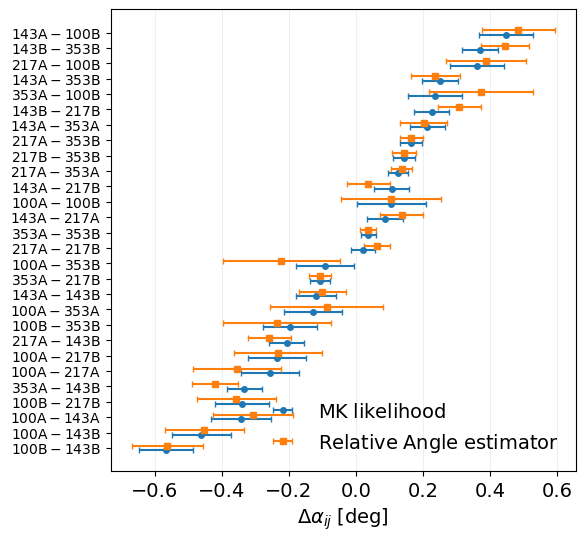

In [5]:
# --- regenerate Fig. 1 with error bars on BOTH series ---
order = np.argsort(mk_pair)
fig, ax = plt.subplots(figsize=(6, 6))
y = np.arange(len(mk_pair))

ax.errorbar(mk_pair[order], y - 0.15, xerr=sig_mk_pair[order], fmt='o', ms=4,
            capsize=2, color='C0', label=r'$\rm{MK\;likelihood}$')
ax.errorbar(rel_pair[order], y + 0.15, xerr=sig_rel_pair[order], fmt='s', ms=4,
            capsize=2, color='C1', label=r'$\rm{Relative\;Angle\;estimator}$')

ax.set_yticks(y)
ax.set_yticklabels([r'$\rm{' + pair_labels[i] + '}$' for i in order], fontsize=10)
ax.set_xlabel(r'$\Delta\alpha_{ij} \; \rm{[deg]}$', fontsize=14)
ax.legend(frameon=False, loc='lower right', fontsize=14)
ax.grid(axis='x', alpha=0.2)
ax.tick_params(axis='x', labelsize=14)
#fig.savefig('pairwise_angles.pdf', bbox_inches='tight', dpi=300)
print('saved pairwise_angles.pdf (both series now have error bars)')
plt.show()


In [6]:
print('==================== RESULT-8 ====================')
print('Corrected PAIRS dict -- paste into paper_figures_standalone.ipynb,')
print('replacing the existing PAIRS block (adds a 4th column: sigma_MK).')
print('PAIRS = {')
for k, (i, j) in enumerate(pairs_idx):
    li, lj = labels[i], labels[j]
    print(f'    ("{li}","{lj}"): ({mk_pair_mean[(li,lj)]:+.4f}, '
          f'{rel_pair[k]:+.4f}, {sig_mk_pair[k]:.4f}, {sig_rel_pair[k]:.4f}),')
print('}')
print('# columns: Dalpha_MK, Dalpha_rel, sigma_MK, sigma_rel')
print('====================================================')


==================== RESULT-8 ====================
Corrected PAIRS dict -- paste into paper_figures_standalone.ipynb,
replacing the existing PAIRS block (adds a 4th column: sigma_MK).
PAIRS = {
    ("100A","143A"): (-0.3423, -0.3066, 0.0890, 0.1199),
    ("100A","217A"): (-0.2559, -0.3552, 0.0859, 0.1307),
    ("100A","353A"): (-0.1295, -0.0880, 0.0868, 0.1688),
    ("100A","100B"): (+0.1052, +0.1051, 0.1022, 0.1487),
    ("100A","143B"): (-0.4623, -0.4522, 0.0881, 0.1168),
    ("100A","217B"): (-0.2360, -0.2327, 0.0869, 0.1303),
    ("100A","353B"): (-0.0922, -0.2231, 0.0876, 0.1741),
    ("143A","217A"): (+0.0864, +0.1359, 0.0529, 0.0650),
    ("143A","353A"): (+0.2128, +0.2019, 0.0524, 0.0704),
    ("143A","100B"): (+0.4474, +0.4835, 0.0819, 0.1088),
    ("143A","143B"): (-0.1200, -0.1002, 0.0594, 0.0712),
    ("143A","217B"): (+0.1062, +0.0369, 0.0531, 0.0650),
    ("143A","353B"): (+0.2500, +0.2360, 0.0542, 0.0734),
    ("217A","353A"): (+0.1264, +0.1366, 0.0302, 0.0319),
    ("21